In [1]:
import numpy as np
from scipy import linalg ,optimize  ,integrate
from optparse import OptionParser
import pandas as pd
from astropy.coordinates import angular_separation as ang 
import astropy.units as u
import sys
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook','grid'])
usage = 'usage: %prog [options]'
parser = OptionParser(usage)

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
c = 299792.458 # km/s
H0 = 70 #(km/s) / Mpc
DES_PATH = '/user/animesh.sah/DES_analysis/DES-SN5YR'

CMBdipdec = -7
CMBdipra = 168
data = pd.read_csv(DES_PATH+'/4_DISTANCES_COVMAT/des_sn5yr.csv',sep='\s+')
nsn = len(data)

#data

In [3]:

alpha = 0.169
beta = 3.14
gamma = 0.033
M0 = -29.96210
#data['mB'] - alpha*data['x1'] + beta*data['c'] - gamma*data['host_mass']

In [15]:
data['HOST_LOGMASS']

0        9.182
1       10.722
2        9.742
3       10.384
4       10.483
         ...  
1815    11.277
1816    10.183
1817    10.902
1818    11.011
1819    10.256
Name: HOST_LOGMASS, Length: 1820, dtype: float64

In [17]:
def delta_hostmass(mass,S = 10, tau = 0.01): 
    return gamma* (1+ np.exp((mass - S)/tau))**(-1) - gamma/2

Text(0, 0.5, '$\\delta_{host}$')

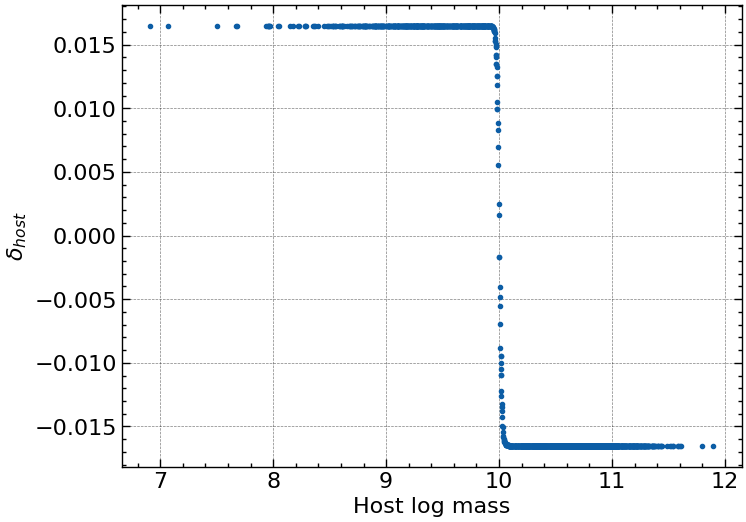

In [25]:
plt.plot(data['HOST_LOGMASS'], delta_hostmass(data['HOST_LOGMASS']),'.')
plt.xlabel('Host log mass')
plt.ylabel('$\delta_{host}$')

In [62]:
mu = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])  - data['biasCor_mu'] +19.32720#+ M0 -19

In [61]:
np.mean(mu - data['MU'])

-19.327209170161638

(array([  4.,   1.,   1.,   0.,   1.,   1.,   2.,   1.,   2.,   1.,   2.,
          5., 124., 619., 777., 237.,  26.,   2.,   2.,   3.,   0.,   2.,
          1.,   2.,   0.,   0.,   2.,   0.,   1.,   1.]),
 array([-19.33907306, -19.33823468, -19.33739629, -19.33655791,
        -19.33571952, -19.33488114, -19.33404275, -19.33320437,
        -19.33236598, -19.3315276 , -19.33068922, -19.32985083,
        -19.32901245, -19.32817406, -19.32733568, -19.32649729,
        -19.32565891, -19.32482052, -19.32398214, -19.32314375,
        -19.32230537, -19.32146698, -19.3206286 , -19.31979022,
        -19.31895183, -19.31811345, -19.31727506, -19.31643668,
        -19.31559829, -19.31475991, -19.31392152]),
 <BarContainer object of 30 artists>)

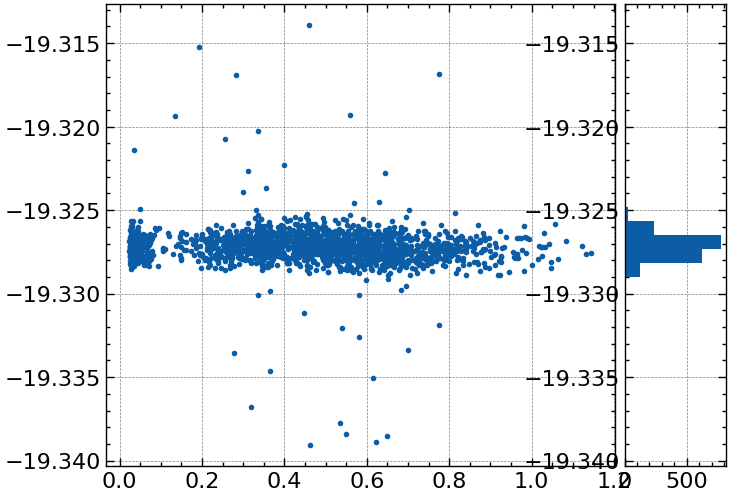

In [60]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots()

residual = mu - data['MU']
ax.plot(data['zHEL'], residual, '.')

divider = make_axes_locatable(ax)
ax_hist = divider.append_axes(
    "right",
    size="20%",
    pad=0.1,
    sharey=ax,
    axes_class=plt.Axes
)

ax_hist.hist(
    residual,
    bins=30,
    orientation='horizontal'
)

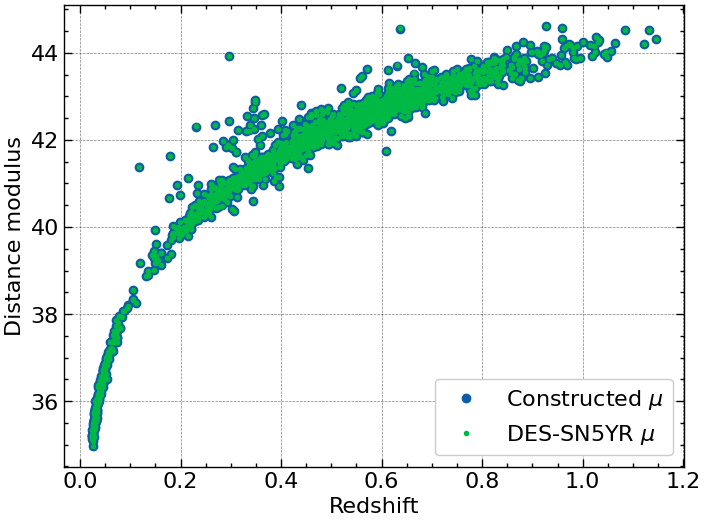

In [64]:
plt.plot(data['zHEL'],mu,'o',label = 'Constructed $\mu$')
plt.plot(data['zHEL'],data['MU'],'.',label = 'DES-SN5YR $\mu$')
plt.xlabel('Redshift')
plt.ylabel('Distance modulus')
plt.legend()

In [68]:
mBCorr_tot = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])  - data['biasCor_mu'] #+19.32720
mBCorr_base = data['mB'] + alpha*data['x1'] - beta*data['c']
mBCorr_hostmass = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])
mBCorr_biascor = data['mB'] + alpha*data['x1'] - beta*data['c']  - data['biasCor_mu']


In [178]:
data['mBCorr_tot'] = mBCorr_tot
data['mBCorr_base'] = mBCorr_base
data['mBCorr_hostmass'] = mBCorr_hostmass
data['mBCorr_biascor'] = mBCorr_biascor

In [132]:
def blockify_covariance(flat_cov, nsn):
    expected = nsn * (nsn + 1) // 2
    assert len(flat_cov) == expected, (
        f"Expected {expected} elements, got {len(flat_cov)}"
    )

    cov = np.zeros((nsn, nsn))
    idx = np.triu_indices(nsn)

    cov[idx] = flat_cov
    cov = cov + cov.T - np.diag(cov.diagonal())

    return cov

In [ ]:
COV = 

In [94]:
def func(Zc,OM,OL,zh=None,zp=None):
        OK= 1.-OM-OL
        def I (z):
            return 1./np.sqrt(OM*(1+z)**3+OL+OK*(1+z)**2)
        if OK==0:
            integ=integrate.quad(I,0,Zc)[0]
        elif OK>0:
            integ= (1./OK)**0.5 *np.sinh(integrate.quad(I,0,Zc)[0]*OK**(0.5))
        elif OK<0:
            integ= (-1./OK)**0.5 *np.sin(integrate.quad(I,0,Zc)[0]*(-OK)**(0.5))
        if zp is not None:
            return (1.+zp)*(1+zh)*integ
        elif zh is not None:
            return (1.+zh)*integ
                        
        return (1.+Zc)*integ
def dL_lcdm(Zc, OM, OL, Zh=None, Zp=None):
    if Zp is not None:
        return np.hstack([func(zc, OM, OL, zh, zp) for zc, zh, zp in zip(Zc, Zh, Zp)])
    elif Zh is not None:
        return np.hstack([func(zc, OM, OL, zh) for zc, zh in zip(Zc, Zh)])
    return np.hstack([func(z, OM, OL) for z in Zc])
def MU_lcdm(Zc, OM, OL):

    k = 25 +5*np.log10((c/H0 )*dL_lcdm(Zc,OM,OL))
            
    if np.any(np.isnan(k)):
        print ('Fuck', OM, OL)
        k[np.isnan(k)] = 63.15861331456834
    return k

In [133]:
covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['cov']

nsn_covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['nsn']
assert nsn == nsn_covmat, f"Number of supernovae in metadata ({nsn}) does not match number in covariance matrix ({nsn_covmat})"

COVd = blockify_covariance(covmat, nsn)

In [134]:
expected = nsn * (nsn + 1) // 2
print(len(covmat), expected)

1657110 1657110


In [135]:
eigmin = np.linalg.eigvalsh(COVd).min()
print(eigmin)

4.565498627559413e-06


In [ ]:
# try:
#     np.linalg.cholesky(COVd)
#     print("Positive definite")
# except np.linalg.LinAlgError:
#     print("Not positive definite")

Positive definite


In [ ]:
def COV(sM=0.045,RV=0):

    COVl=np.diag((sM**2)*np.ones(nsn))
    
    if RV==0: 
        return np.array(COVl+COVd)
    elif RV==1:
        return np.array( COVd )
    elif RV==2:        
        return np.array(COVl)
  
def lkly( M0,OM,OL,z='zHEL'):
    Y0 = np.array([ M0])
    mu = MU_lcdm(np.array(np.array(data[z])), OM,OL) ;
    return np.hstack( [ (np.array(data['mBCorr_hostmass']) - mu - Y0 )  ] )  


In [259]:
mu = MU_lcdm(np.array(np.array(data['zHEL'])), 0.3,0.7)
Y0 = np.array([ pre_found_best[0] ])
res = np.hstack( [ (np.array(data['mBCorr_hostmass']) - mu - Y0 )  ] )  

(array([  1.,   0.,   2.,   5.,   9.,   8.,  18.,  29.,  46.,  70., 112.,
        197., 271., 282., 297., 177., 109.,  63.,  35.,  21.,   8.,  10.,
         11.,   3.,   3.,  10.,   5.,   4.,   2.,   1.,   1.,   1.,   1.,
          2.,   1.,   1.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   1.]),
 array([-1.13911808, -1.05513339, -0.9711487 , -0.88716402, -0.80317933,
        -0.71919464, -0.63520996, -0.55122527, -0.46724058, -0.38325589,
        -0.29927121, -0.21528652, -0.13130183, -0.04731715,  0.03666754,
         0.12065223,  0.20463692,  0.2886216 ,  0.37260629,  0.45659098,
         0.54057566,  0.62456035,  0.70854504,  0.79252973,  0.87651441,
         0.9604991 ,  1.04448379,  1.12846847,  1.21245316,  1.29643785,
         1.38042254,  1.46440722,  1.54839191,  1.6323766 ,  1.71636128,
         1.80034597,  1.88433066,  1.96831535,  2.05230003,  2.13628472,
         2.22026941,  2.30425409,  2.38823878,  2.47222347,  2.55620816,
 

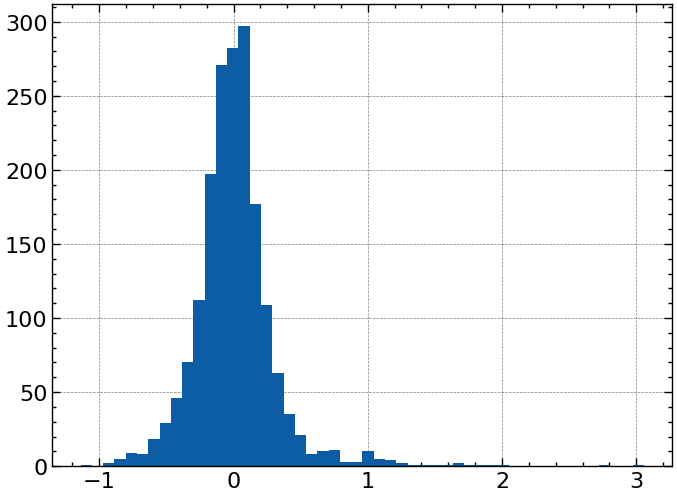

In [258]:
plt.hist(res, bins=50)

In [261]:
def cdAngle(l1, b1, l2, b2):
        return np.cos(np.deg2rad(b1))*np.cos(np.deg2rad(b2))*np.cos(np.deg2rad(l1) - np.deg2rad(l2))+np.sin(np.deg2rad(b1))*np.sin(np.deg2rad(b2))


In [262]:
mu = MU_lcdm(np.array(np.array(data['zHEL'])), 0.3,0.7) 

In [263]:
lkly(pre_found_best[0], pre_found_best[1], pre_found_best[2])

array([ 0.1030224 , -0.18063359, -0.27607033, ..., -0.17298952,
        0.1534522 , -0.11444479])

In [270]:
COVd

array([[ 3.09844036e+01, -4.54146648e-03,  4.17804606e-02, ...,
        -9.10215527e-02, -1.36731500e-02, -1.63338933e-04],
       [-4.54146648e-03,  3.67668076e+01, -1.52099073e-01, ...,
        -1.91784680e-01, -7.96624869e-02, -1.30355107e-02],
       [ 4.17804606e-02, -1.52099073e-01,  5.53851738e+01, ...,
        -1.25856966e-01, -1.99649215e-01, -3.19006324e-01],
       ...,
       [-9.10215527e-02, -1.91784680e-01, -1.25856966e-01, ...,
         8.28135681e+01, -6.59430444e-01, -7.79742241e-01],
       [-1.36731500e-02, -7.96624869e-02, -1.99649215e-01, ...,
        -6.59430444e-01,  3.84698448e+01, -1.41770589e+00],
       [-1.63338933e-04, -1.30355107e-02, -3.19006324e-01, ...,
        -7.79742241e-01, -1.41770589e+00,  4.17195244e+01]])

In [269]:
COV( *[ pre_found_best[i] for i in [1] ])

array([[ 3.09853036e+01, -4.54146648e-03,  4.17804606e-02, ...,
        -9.10215527e-02, -1.36731500e-02, -1.63338933e-04],
       [-4.54146648e-03,  3.67677076e+01, -1.52099073e-01, ...,
        -1.91784680e-01, -7.96624869e-02, -1.30355107e-02],
       [ 4.17804606e-02, -1.52099073e-01,  5.53860738e+01, ...,
        -1.25856966e-01, -1.99649215e-01, -3.19006324e-01],
       ...,
       [-9.10215527e-02, -1.91784680e-01, -1.25856966e-01, ...,
         8.28144681e+01, -6.59430444e-01, -7.79742241e-01],
       [-1.36731500e-02, -7.96624869e-02, -1.99649215e-01, ...,
        -6.59430444e-01,  3.84707448e+01, -1.41770589e+00],
       [-1.63338933e-04, -1.30355107e-02, -3.19006324e-01, ...,
        -7.79742241e-01, -1.41770589e+00,  4.17204244e+01]])

In [281]:
chol_fac = linalg.cho_factor(COVd, overwrite_a = True, lower = True )
chol_fac[0].shape

(1820, 1820)

In [309]:
def m2loglike(pars , RV = 0):
        if RV != 0 and RV != 1 and RV != 2:
            raise ValueError('Inappropriate RV value')
        else:

            cov = COV( *[ pars[i] for i in [1] ] )
            

                 
            try:
                chol_fac = linalg.cho_factor(cov, overwrite_a = True, lower = True )
            except np.linalg.linalg.LinAlgError: # If not positive definite
                return +13993*10.**20 
            except ValueError: # If contains infinity
                return 13995*10.**20
            

            res=lkly(*[pars[i] for i,val in enumerate(pars) if i!=1])
            #print(len(res))
            #plt.hist(res, bins=50)
            part_log = nsn*np.log(2*np.pi) + np.sum( np.log( np.diag( chol_fac[0] ) ) ) * 2
            
            part_exp = np.dot( res, linalg.cho_solve( chol_fac, res) )

            # if pars[0]<0 or pars[1]<0 or pars[1]>1 or pars[0]>1:
            #         pass
                    #part_exp += 100* np.sum(np.array([ _**2 for _ in pars ]))
            print(part_exp,pars)
            if RV==0:
                m2loglike = part_log + part_exp
                print('part_log:', part_log, 'part_exp:', part_exp)
                print('pars:', pars, 'm2loglike:', m2loglike)
                return m2loglike 
            elif RV==1: 
                return part_exp 
            elif RV==2:
                return part_log  

In [306]:
pre_found_best=[-19.2 ,0.03,0.3,0.7   ]
bounds = [(-30, -10), (0, None), (None, None), (None, None)]

In [307]:
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

70740.07723599281 [-19.2    0.03   0.3    0.7 ]
part_log: 9079.210870725989 part_exp: 70740.07723599281
pars: [-19.2    0.03   0.3    0.7 ] m2loglike: 79819.2881067188
70740.07639796074 [-19.19999999   0.03         0.3          0.7       ]
part_log: 9079.210870725989 part_exp: 70740.07639796074
pars: [-19.19999999   0.03         0.3          0.7       ] m2loglike: 79819.28726868673
70740.03169425504 [-19.2          0.03000001   0.3          0.7       ]
part_log: 9079.210914734645 part_exp: 70740.03169425504
pars: [-19.2          0.03000001   0.3          0.7       ] m2loglike: 79819.24260898969
70740.07743973543 [-19.2          0.03         0.30000001   0.7       ]
part_log: 9079.210870725989 part_exp: 70740.07743973543
pars: [-19.2          0.03         0.30000001   0.7       ] m2loglike: 79819.28831046142
70740.07701348927 [-19.2          0.03         0.3          0.70000001]
part_log: 9079.210870725989 part_exp: 70740.07701348927
pars: [-19.2          0.03         0.3          0.700

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 9702.801723577952
        x: [-1.876e+01  6.815e-01  2.099e+00  1.882e+00]
      nit: 27
      jac: [-1.819e-04 -3.638e-04  1.819e-04  0.000e+00]
     nfev: 190
     njev: 38
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [148]:
m2loglike(pre_found_best)

KeyError: "None of [Index([      15.921951666, 15.656695130000001, 15.626611702000206,\n             15.723581886, 15.797326382000003, 15.827816859999999,\n       15.973691220000001,  15.96327945400102,       15.825701393,\n             15.792205412,\n       ...\n        24.91334099453839, 24.320739022020003,       24.356342828,\n       24.932721829000002, 24.044630010000002,        25.45096824,\n        25.20824107762767,       24.942630324,        25.29348053,\n        25.06107327999975],\n      dtype='float64', length=1820)] are in the [columns]"